# Beliebtheitssortierung v2 – Buchungswahrscheinlichkeit pro Hotel

**Autorin:** Lena (Data Science Hotel) · **Stand:** Sept. 2026

Ziel: Für eine Suche (Reisezeitraum, Gerät, Nutzersegment) und eine Liste von Hotels die Buchungswahrscheinlichkeit schätzen und die Hotels danach sortieren ("Beliebtheit"-Sortierung in der Ergebnisliste).

Daten: Export der Such-Impressions der letzten 3 Monate (`data/impressions.csv`).

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, ndcg_score

pd.set_option('display.max_columns', 30)

## Daten laden

In [2]:
df = pd.read_csv('data/impressions.csv')
print(df.shape)
df.head()

(60000, 18)


,search_id,search_date,days_until_checkin,stay_length,device,user_segment,hotel_id,city,stars,rating,review_count,price_per_night,distance_to_center_km,has_pool,breakfast_included,free_cancellation,position,booked
0,S100059,2026-06-01,40,1,tablet,family,H1235,Berlin,5,7.8,658,224.53,2.55,0,0,1,1,0
1,S100059,2026-06-01,40,1,tablet,family,H1085,Berlin,3,8.5,369,173.93,3.54,0,0,1,2,0
2,S100059,2026-06-01,40,1,tablet,family,H1263,Berlin,2,7.0,79,140.16,2.80,0,0,0,3,0
3,S100059,2026-06-01,40,1,tablet,family,H1262,Berlin,4,8.6,178,171.07,5.60,0,0,0,4,0
4,S100059,2026-06-01,40,1,tablet,family,H1208,Berlin,2,7.3,445,132.73,2.45,0,1,1,5,0


In [3]:
df.describe()

,days_until_checkin,stay_length,stars,rating,review_count,price_per_night,distance_to_center_km,has_pool,breakfast_included,free_cancellation,position,booked
count,60000.000000,60000.000000,60000.000000,56493.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,26.033500,3.617833,3.271983,7.910104,461.696517,167.942513,2.709721,0.216950,0.417417,0.585733,5.500000,0.069000
std,21.446493,2.922486,0.959682,0.739057,348.947546,50.454816,2.078316,0.412172,0.493137,0.492599,2.872305,0.253456
min,1.000000,1.000000,1.000000,5.400000,0.000000,61.580000,0.010000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,10.000000,2.000000,3.000000,7.400000,210.000000,132.830000,1.120000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,20.000000,3.000000,3.000000,8.000000,403.000000,161.350000,2.300000,0.000000,0.000000,1.000000,5.500000,0.000000
75%,36.000000,4.000000,4.000000,8.400000,628.000000,199.110000,3.750000,0.000000,1.000000,1.000000,8.000000,0.000000
max,184.000000,14.000000,5.000000,9.800000,2069.000000,332.350000,12.620000,1.000000,1.000000,1.000000,10.000000,1.000000


In [4]:
print('Buchungsrate gesamt:', round(df.booked.mean(), 4))
df.groupby(['user_segment', 'device']).booked.mean().unstack()

Buchungsrate gesamt: 0.069


device,desktop,mobile,tablet
user_segment,,,
business,0.064751,0.057683,0.065421
family,0.082308,0.073763,0.080909
leisure,0.073684,0.065539,0.072778


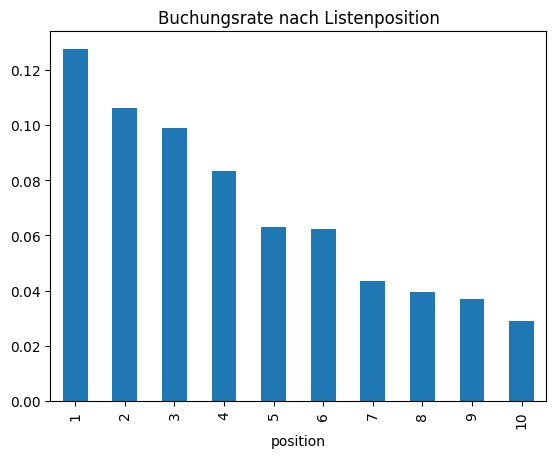

In [5]:
df.groupby('position').booked.mean().plot(kind='bar', title='Buchungsrate nach Listenposition')
plt.show()

## Cleaning
Neue Hotels haben noch kein Rating → mit dem Mittelwert auffüllen.

In [6]:
print('fehlende Ratings:', df.rating.isna().sum())
rating_mean = df.rating.mean()
print('Mittelwert:', round(rating_mean, 2))
df['rating'] = df['rating'].fillna(rating_mean)

fehlende Ratings: 3507
Mittelwert: 7.91


## Features

In [7]:
df['price_per_star'] = df.price_per_night / df.stars
df['log_reviews'] = np.log1p(df.review_count)
df['early_booking'] = (df.days_until_checkin > 30).astype(int)

features = ['days_until_checkin', 'stay_length', 'stars', 'rating', 'log_reviews',
            'price_per_night', 'price_per_star', 'distance_to_center_km', 'has_pool',
            'breakfast_included', 'free_cancellation', 'early_booking', 'position',
            'device', 'user_segment', 'city']

X = pd.get_dummies(df[features], columns=['device', 'user_segment', 'city'])
y = df.booked
X.shape

(60000, 24)

## Training

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=31)
model.fit(X_train, y_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_d

## Evaluation

In [9]:
p_test = model.predict_proba(X_test)[:, 1]
print('AUC:', round(roc_auc_score(y_test, p_test), 4))

# NDCG@5 pro Suche (nur Suchen mit Buchung im Testset)
ev = df.loc[X_test.index, ['search_id']].assign(y=y_test.values, p=p_test)
scores = []
for _, g in ev.groupby('search_id'):
    if g.y.sum() > 0 and len(g) > 1:
        scores.append(ndcg_score([g.y.values], [g.p.values], k=5))
print('NDCG@5:', round(np.mean(scores), 4), '| Suchen:', len(scores))

AUC: 0.7014


NDCG@5: 0.8187 | Suchen: 755


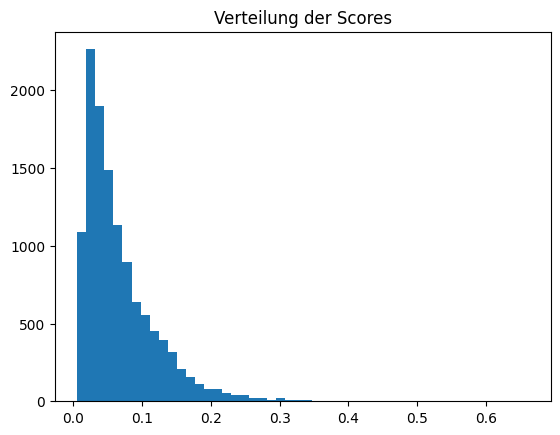

In [10]:
plt.hist(p_test, bins=50)
plt.title('Verteilung der Scores')
plt.show()

## Modell speichern

In [11]:
with open('model_final_v2.pkl', 'wb') as f:
    pickle.dump(model, f)
print('gespeichert')

gespeichert


## So würde man neue Hotels scoren
Beispiel: eine Familie sucht auf dem Handy, Check-in in 45 Tagen, 7 Nächte, Palma.

In [12]:
search = {'days_until_checkin': 45, 'stay_length': 7, 'device': 'mobile', 'user_segment': 'family'}
hotels = pd.DataFrame([
    {'hotel_id': 'H1234', 'city': 'Palma', 'stars': 4, 'rating': 8.7, 'review_count': 812,
     'price_per_night': 164.0, 'distance_to_center_km': 3.1, 'has_pool': 1,
     'breakfast_included': 1, 'free_cancellation': 1},
    {'hotel_id': 'H1377', 'city': 'Palma', 'stars': 3, 'rating': None, 'review_count': 0,
     'price_per_night': 98.0, 'distance_to_center_km': 0.8, 'has_pool': 0,
     'breakfast_included': 0, 'free_cancellation': 1},
    {'hotel_id': 'H1012', 'city': 'Palma', 'stars': 5, 'rating': 9.1, 'review_count': 455,
     'price_per_night': 310.0, 'distance_to_center_km': 6.4, 'has_pool': 1,
     'breakfast_included': 1, 'free_cancellation': 0},
])
new = hotels.assign(**search)
new['rating'] = new['rating'].fillna(7.91)
new['price_per_star'] = new.price_per_night / new.stars
new['log_reviews'] = np.log1p(new.review_count)
new['early_booking'] = (new.days_until_checkin > 30).astype(int)
new['position'] = 1
X_new = pd.get_dummies(new[features], columns=['device', 'user_segment', 'city'])
X_new = X_new.reindex(columns=X.columns, fill_value=0)

hotels['score'] = model.predict_proba(X_new)[:, 1]
hotels.sort_values('score', ascending=False)[['hotel_id', 'score']]

,hotel_id,score
0,H1234,0.366097
1,H1377,0.121106
2,H1012,0.108304


## Offene Punkte / Notizen
- Produkt möchte das Modell in der Ergebnisliste nutzen: pro Suche kommen ca. 50–200 Hotels, Antwortzeit sollte < 50 ms sein.
- Modell sollte regelmäßig (nächtlich?) neu trainiert werden, neue Daten kommen täglich.
- Läuft bei mir lokal mit Python 3.12 – `requirements.txt` liegt bei.
- Fragen gerne an mich 🙂